# AICE Associate 시험대비 수업 자료
## 지도학습으로 AI 모델링하기

---
| 교시 | 주제 | 시간 |
|------|------|------|
| 1교시 | AI 필수 개념 + 데이터 분할 + 과적합 | 50분 |
| 2교시 | 모델 평가 + 선형회귀 + 로지스틱회귀 | 50분 |
| 3교시 | 트리 기반 모델 + 실전 문제 | 50분 |

In [1]:
# ============================================================
# 수업 전체에서 사용할 라이브러리 한 번에 임포트
# ============================================================

import pandas as pd                  # 데이터프레임 처리 (표 형식 데이터)
import numpy as np                   # 수치 계산, 배열 처리
import matplotlib.pyplot as plt      # 그래프 그리기
import seaborn as sns                # 고급 시각화 (matplotlib 기반)
import warnings
warnings.filterwarnings('ignore')    # 경고 메시지 숨기기

# sklearn.datasets: 연습용 내장 데이터셋 제공
from sklearn.datasets import load_iris, load_diabetes

# train_test_split : 데이터를 학습/테스트로 분리
# cross_val_score  : K-Fold 교차 검증 수행
# KFold            : 교차 검증 분할 방법 설정
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# StandardScaler: 평균=0, 표준편차=1로 변환하는 스케일러
from sklearn.preprocessing import StandardScaler

# accuracy_score      : 분류 정확도 계산
# classification_report: Precision, Recall, F1 한 번에 출력
# confusion_matrix    : 오차(혼동) 행렬 계산
# mean_squared_error  : 회귀 MSE 계산
# r2_score            : 회귀 R² 계산
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, mean_squared_error, r2_score)

# 주피터 노트북 그래프 출력 (셀 아래에 바로 표시)
%matplotlib inline

# 한글 폰트 설정 (Mac)
plt.rcParams['font.family'] = 'AppleGothic'  # 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False   # 마이너스(-) 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (12, 6)     # 그래프 기본 크기 (가로, 세로 인치)

print("라이브러리 임포트 완료!")

라이브러리 임포트 완료!


# 🕐 1교시: AI 모델링 필수 개념 (50분)
---
## 1. AI란 무엇인가? — 머신러닝 vs 딥러닝

### 한 줄 정의
> **AI(인공지능)**: 컴퓨터가 데이터에서 스스로 규칙을 찾아 판단하는 기술

### 직관적 비유

| | 전통 프로그래밍 | 머신러닝 |
|---|---|---|
| 방식 | 사람이 규칙을 직접 코드로 작성 | **데이터에서 규칙을 스스로 학습** |
| 비유 | 요리 레시피를 직접 알려줌 | 음식을 먹어보고 레시피를 스스로 추론 |

```
AI (인공지능)
├── 머신러닝: 데이터에서 패턴을 학습 (통계 기반)
│   ├── 지도학습: 정답이 있는 데이터로 학습 ← AICE 주요 범위
│   └── 비지도학습: 정답 없이 구조를 발견
└── 딥러닝: 머신러닝의 일종, 신경망(뇌 구조 모방)
```

### 📝 시험 출제 포인트
- **머신러닝** → sklearn 라이브러리 (DecisionTree, RandomForest, LogisticRegression 등)
- **딥러닝** → keras/tensorflow 라이브러리 (Dense, LSTM 등)
- AICE Associate는 **머신러닝 비중이 높음**

### ⚠️ 자주 하는 실수
- 딥러닝 = AI 전부라고 생각 → 딥러닝은 AI의 한 종류
- 머신러닝은 항상 딥러닝보다 성능이 낮다 → **데이터가 적을 때는 머신러닝이 더 좋을 수 있음**

## 2. AI 학습 방법 — 지도학습 vs 비지도학습

### 직관적 비유

| | 지도학습 | 비지도학습 |
|---|---|---|
| 비유 | 정답지가 있는 문제집으로 공부 | 정답 없이 스스로 패턴 발견 |
| 데이터 | X(입력) + y(정답) | X(입력)만 |
| 목적 | 예측/분류 | 군집화/차원축소 |
| 예시 | 스팸메일 분류, 집값 예측 | 고객 세분화, 이상 탐지 |
| sklearn | `fit(X_train, y_train)` | `fit(X)` |

### 지도학습의 두 종류

```
지도학습
├── 분류(Classification): y가 카테고리 → "생존/사망", "스팸/정상"
│   └── LogisticRegression, DecisionTree, RandomForest
└── 회귀(Regression): y가 연속값 → "집값", "온도"
    └── LinearRegression, Ridge, Lasso
```

### 📝 시험 출제 포인트
- y 값이 **0/1, 카테고리** → 분류 모델 사용
- y 값이 **숫자(연속)** → 회귀 모델 사용
- 평가지표도 달라짐: 분류→Accuracy/F1, 회귀→RMSE/R²

## 3. AI 모델링 프로세스

```
① 데이터 수집
        ↓
② EDA (탐색적 데이터 분석) — 분포, 결측치, 이상치 확인
        ↓
③ 전처리 — 결측치 처리, 인코딩, 스케일링
        ↓
④ 데이터 분할 — X_train, X_test, y_train, y_test
        ↓
⑤ 모델 선택 & 학습 — model.fit(X_train, y_train)
        ↓
⑥ 예측 — y_pred = model.predict(X_test)
        ↓
⑦ 평가 — accuracy_score, r2_score 등
        ↓
⑧ 튜닝 — 하이퍼파라미터 조정, 피처 엔지니어링
```

### 📝 시험 출제 포인트
- **fit()은 train 데이터로만**, predict()는 test 데이터로
- **스케일러도 train으로 fit** 후 test는 transform만 (data leakage 방지)

## 4. 학습 데이터 분할

### 직관적 비유
> 시험 공부할 때 **모의고사(test)**를 따로 빼두고, **교과서(train)**로만 공부하는 것과 같다.  
> 모의고사를 미리 풀어보면 그 답을 외워버려서 진짜 실력을 알 수 없다.

### train_test_split
- `test_size`: 테스트 비율 (보통 0.2 = 20%)
- `random_state`: 매번 같은 결과를 위한 시드값
- `stratify`: 클래스 비율을 동일하게 유지 **(불균형 데이터 필수!)**

In [2]:
# ============================================================
# 학습/테스트 데이터 분할 실습 (iris 데이터셋 사용)
# ============================================================

# load_iris(): 붓꽃 품종 데이터 (150행, 4개 피처, 3개 클래스)
iris = load_iris()

# 독립변수(X): 꽃받침/꽃잎의 길이·너비 4개 컬럼
X = pd.DataFrame(iris.data, columns=iris.feature_names)

# 종속변수(y): 품종 (0=setosa, 1=versicolor, 2=virginica)
y = pd.Series(iris.target, name='species')

print(f"전체 데이터: {X.shape}")               # (행 수, 열 수)
print(f"클래스 분포:\n{y.value_counts().sort_index()}\n")

# ---------------------------------------------------------
# train_test_split: 데이터를 학습용/테스트용으로 나누는 함수
#   X, y        : 분리할 독립변수와 종속변수
#   test_size   : 테스트 비율 (0.2 = 전체의 20%)
#   random_state: 분할 결과 고정 (같은 숫자면 항상 동일하게 분리됨)
#   stratify    : 지정한 y의 클래스 비율을 유지하며 분리
#                 ← 불균형 데이터에서 반드시 사용!
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\nTrain 클래스 비율:\n{y_train.value_counts().sort_index()}")
print(f"\nTest  클래스 비율:\n{y_test.value_counts().sort_index()}")

전체 데이터: (150, 4)
클래스 분포:
species
0    50
1    50
2    50
Name: count, dtype: int64

Train: (120, 4)  |  Test: (30, 4)

Train 클래스 비율:
species
0    40
1    40
2    40
Name: count, dtype: int64

Test  클래스 비율:
species
0    10
1    10
2    10
Name: count, dtype: int64


### K-Fold 교차 검증 (Cross-Validation)

### 직관적 비유
> 데이터를 K등분하여 **번갈아가며 모의고사지를 바꿔서** 총 K번 시험을 보고 평균 점수를 구한다.  
> 한 번의 분할에 의존하지 않아 **더 신뢰할 수 있는 성능 측정** 가능.

```
K=5 일 때:
[1] [2] [3] [4] [5]
 ↑   ← 1회차: 1번 블록이 test, 나머지 4개가 train
     ↑  ← 2회차: 2번 블록이 test
         ↑  ← 3회차 ...
```

### 📝 시험 출제 포인트
- `cross_val_score(model, X, y, cv=5)` — cv: 폴드 수
- 결과는 **배열(각 폴드의 점수)**로 반환 → `.mean()`으로 평균 사용
- 데이터 수가 적을 때 특히 유용

In [3]:
# ============================================================
# K-Fold 교차 검증 실습
# ============================================================
from sklearn.tree import DecisionTreeClassifier

# DecisionTreeClassifier: 의사결정나무 분류 모델
#   random_state: 결과 고정 (같은 숫자면 항상 동일한 결과)
model = DecisionTreeClassifier(random_state=42)

# ---------------------------------------------------------
# cross_val_score: K-Fold 교차 검증을 자동으로 수행하는 함수
#   estimator : 사용할 모델
#   X, y      : 전체 데이터 (분할 없이 전달 → 함수가 알아서 분할)
#   cv        : 폴드(분할) 수 (cv=5 → 5번 나눠서 검증)
#   scoring   : 평가 기준 ('accuracy'=정확도, 'f1_macro'=F1 등)
# 반환값: 각 폴드의 점수를 담은 배열
# ---------------------------------------------------------

# Accuracy: 전체 중 맞힌 비율
acc_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

# F1 (macro): 클래스별 F1을 계산 후 단순 평균
#   → 다중 분류(클래스 3개)일 때 클래스 불균형을 고려한 종합 지표
#   macro  : 클래스별 F1을 동등하게 평균 (클래스 크기 무시)
#   weighted: 클래스 샘플 수 비례로 가중 평균 (불균형 데이터에 적합)
f1_scores  = cross_val_score(model, X, y, cv=5, scoring='f1_macro')

print("=== 5-Fold 교차 검증 결과 ===")
print(f"{'폴드':>5} | {'Accuracy':>10} | {'F1 (macro)':>10}")
print("-" * 35)
for i, (acc, f1) in enumerate(zip(acc_scores, f1_scores), 1):
    print(f"  {i}번째   |   {acc:.4f}   |   {f1:.4f}")

print("-" * 35)
# .mean(): 5번 결과의 평균 → 모델의 대표 성능
# .std() : 5번 결과의 표준편차 → 작을수록 결과가 안정적
print(f"  평균    |   {acc_scores.mean():.4f}   |   {f1_scores.mean():.4f}")
print(f"  표준편차|   {acc_scores.std():.4f}   |   {f1_scores.std():.4f}  ← 작을수록 안정적")
print()
print("📌 해석 가이드:")
print("  - Accuracy ≈ F1  → 클래스 분포가 균등한 데이터")
print("  - Accuracy >> F1 → 클래스 불균형 가능성 → F1을 신뢰")

=== 5-Fold 교차 검증 결과 ===
   폴드 |   Accuracy | F1 (macro)
-----------------------------------
  1번째   |   0.9667   |   0.9666
  2번째   |   0.9667   |   0.9666
  3번째   |   0.9000   |   0.8997
  4번째   |   0.9333   |   0.9333
  5번째   |   1.0000   |   1.0000
-----------------------------------
  평균    |   0.9533   |   0.9532
  표준편차|   0.0340   |   0.0341  ← 작을수록 안정적

📌 해석 가이드:
  - Accuracy ≈ F1  → 클래스 분포가 균등한 데이터
  - Accuracy >> F1 → 클래스 불균형 가능성 → F1을 신뢰


## 5. 과적합 (Overfitting)

### 직관적 비유
> **족보만 달달 외운 학생** — 족보 문제(train)는 100점, 실제 시험(test)은 50점  
> **진짜 실력을 키운 학생** — 족보 문제 85점, 실제 시험 82점 ← 이게 좋은 모델

| 상태 | Train 점수 | Test 점수 | 조치 |
|------|-----------|-----------|------|
| 과소적합 | 낮음 | 낮음 | 모델 복잡도 증가, 피처 추가 |
| **적절** | 높음 | 높음 | ✅ 이상적 |
| **과적합** | 매우 높음 | 낮음 | 규제, 데이터 추가, 단순화 |

### 과적합 방지 방법
- `max_depth` 제한 (트리 모델)
- `Ridge`, `Lasso` 규제 (선형 모델)
- 데이터 수 늘리기
- `Dropout` (딥러닝)

최적 depth: 3  (Test 정확도 최고: 0.9667)


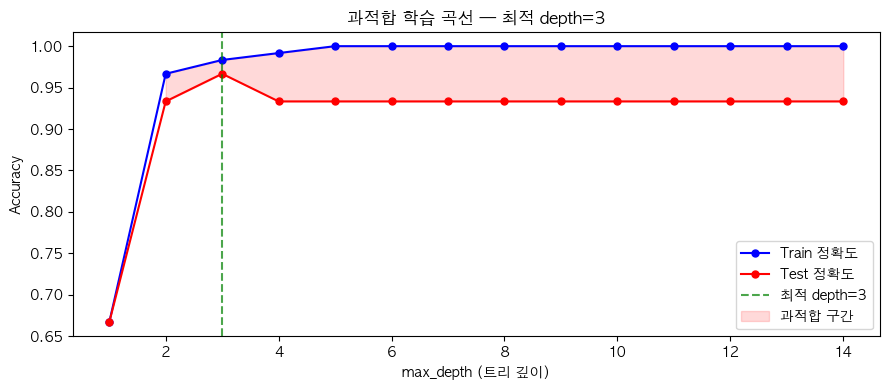

→ Train/Test 간격이 클수록 과적합!


In [4]:
# ============================================================
# 과적합 시각화 — max_depth에 따른 Train/Test 정확도 비교
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# depth를 1~14까지 바꿔가며 Train/Test 정확도 기록
depths = range(1, 15)
train_scores, test_scores = [], []

for depth in depths:
    # max_depth: 트리가 질문을 최대 몇 번 할 수 있는지 (깊이 제한)
    #            값이 클수록 복잡한 트리 → 과적합 위험
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))  # 학습 정확도
    test_scores.append(accuracy_score(y_test,  m.predict(X_test)))    # 테스트 정확도

# ---------------------------------------------------------
# Test 정확도가 가장 높은 depth를 자동으로 찾기
#   test_scores.index(max(test_scores)) : 최댓값의 위치(인덱스)
#   depths[인덱스] : 해당 위치의 depth 값
# ---------------------------------------------------------
best_depth = list(depths)[test_scores.index(max(test_scores))]
print(f"최적 depth: {best_depth}  (Test 정확도 최고: {max(test_scores):.4f})")

# ---------------------------------------------------------
# 그래프 그리기
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))

# ax.plot: 선 그래프
#   'b-o' : 파란색(b) 실선(-) 원형마커(o)
#   'r-o' : 빨간색(r) 실선(-) 원형마커(o)
ax.plot(depths, train_scores, 'b-o', label='Train 정확도', markersize=5)
ax.plot(depths, test_scores,  'r-o', label='Test 정확도',  markersize=5)

# axvline: 수직 기준선 — best_depth 위치에 자동으로 표시
ax.axvline(x=best_depth, color='green', linestyle='--', alpha=0.7,
           label=f'최적 depth={best_depth}')

# fill_between: Train > Test 구간(과적합 구간)을 빨간색으로 표시
ax.fill_between(depths, train_scores, test_scores,
                where=[t > te for t, te in zip(train_scores, test_scores)],
                alpha=0.15, color='red', label='과적합 구간')

ax.set_xlabel('max_depth (트리 깊이)')
ax.set_ylabel('Accuracy')
ax.set_title(f'과적합 학습 곡선 — 최적 depth={best_depth}')
ax.legend()
plt.tight_layout()
plt.show()
print("→ Train/Test 간격이 클수록 과적합!")

# 🕑 2교시: 모델 평가 + 선형/로지스틱 회귀 (50분)
---
## 1. 분류 모델 평가 지표

### 오차(혼동) 행렬 (Confusion Matrix)

```
                  예측: 음성(0)    예측: 양성(1)
실제: 음성(0)       TN(진음성)      FP(위양성)   ← 실제 사망인데 생존 예측
실제: 양성(1)       FN(위음성)      TP(진양성)   ← 실제 생존인데 사망 예측
```

| 지표 | 공식 | 의미 | 비유 |
|------|------|------|------|
| **Accuracy** | (TP+TN) / 전체 | 전체 중 맞힌 비율 | 시험 점수 |
| **Precision** | TP / (TP+FP) | 양성 예측 중 진짜 양성 | 낚시꾼의 명중률 |
| **Recall** | TP / (TP+FN) | 실제 양성 중 찾아낸 비율 | 범인을 놓치지 않는 능력 |
| **F1-Score** | 2×P×R / (P+R) | Precision과 Recall의 균형 | 종합 점수 |

### 📝 시험 출제 포인트
- **불균형 데이터**에서는 Accuracy가 높아도 의미없음 → **F1-Score** 사용
- 암 진단처럼 **놓치면 안 되는 경우** → **Recall** 중요
- 스팸 필터처럼 **잘못 걸리면 안 되는 경우** → **Precision** 중요

Accuracy : 1.0000

              precision    recall  f1-score   support

       기타(0)       1.00      1.00      1.00        20
   Setosa(1)       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



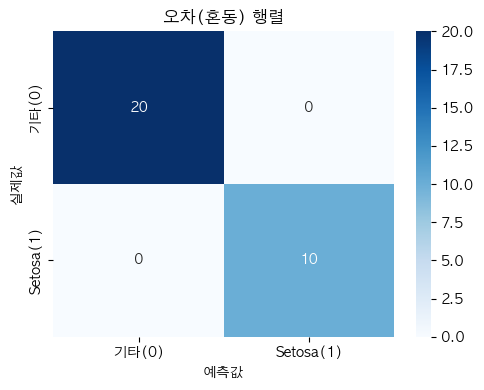

In [5]:
# ============================================================
# 분류 평가 지표 실습 (iris 이진분류: setosa(0) vs 나머지(1))
# ============================================================
from sklearn.linear_model import LogisticRegression

iris = load_iris()
X_cls = pd.DataFrame(iris.data, columns=iris.feature_names)

# (iris.target == 0): setosa이면 True(1), 아니면 False(0)
# .astype(int): True/False → 1/0 정수로 변환
y_cls = (iris.target == 0).astype(int)

# stratify=y_cls: 클래스 비율 유지하며 분리
X_tr, X_te, y_tr, y_te = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

# ---------------------------------------------------------
# StandardScaler: 각 컬럼을 평균=0, 표준편차=1로 표준화
#   fit_transform: train으로 평균/표준편차를 계산하고 변환
#   transform    : 계산된 값으로 test만 변환 (fit 하지 않음!)
#                  ← test에 fit하면 데이터 누수(data leakage) 발생
# ---------------------------------------------------------
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)  # train: 계산 + 변환
X_te_s = sc.transform(X_te)      # test: 변환만

# LogisticRegression: 이진분류 모델 (시그모이드 함수 적용)
#   random_state: 결과 재현성 보장
clf = LogisticRegression(random_state=42)
clf.fit(X_tr_s, y_tr)             # 학습
y_pred_cls = clf.predict(X_te_s)  # 예측

print(f"Accuracy : {accuracy_score(y_te, y_pred_cls):.4f}")
print()

# classification_report: Precision, Recall, F1을 한 번에 출력
#   target_names: 클래스 이름 지정 (0→'기타', 1→'Setosa')
print(classification_report(y_te, y_pred_cls, target_names=['기타(0)', 'Setosa(1)']))

# ---------------------------------------------------------
# 오차(혼동) 행렬(Confusion Matrix) 시각화
# confusion_matrix: 실제값 vs 예측값의 개수를 표로 반환
# ---------------------------------------------------------
cm = confusion_matrix(y_te, y_pred_cls)
fig, ax = plt.subplots(figsize=(5, 4))

# sns.heatmap: 숫자 표를 색상으로 시각화
#   annot  : True → 각 칸에 숫자 표시
#   fmt='d': 정수(integer) 형식으로 표시
#   cmap   : 색상 팔레트 ('Blues'=파란계열)
#   xticklabels/yticklabels: x축/y축 레이블 이름
#   ax     : 그릴 axes 객체 지정
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['기타(0)', 'Setosa(1)'],
            yticklabels=['기타(0)', 'Setosa(1)'],
            ax=ax)
ax.set_xlabel('예측값')
ax.set_ylabel('실제값')
ax.set_title('오차(혼동) 행렬')
plt.tight_layout()
plt.show()

## 2. 회귀 모델 평가 지표

| 지표 | 공식 | 의미 | 단위 |
|------|------|------|------|
| **MAE** | 평균 \|실제-예측\| | 평균 오차 크기 | 원래 단위 |
| **MSE** | 평균 (실제-예측)² | 큰 오차에 더 민감 | 단위² |
| **RMSE** | √MSE | MSE의 제곱근 (직관적) | 원래 단위 |
| **R²** | 1 - SSres/SStot | 모델이 분산을 설명하는 비율 | 0~1 |

### 📝 시험 출제 포인트
- **R² = 1** → 완벽한 예측, **R² = 0** → 평균 예측과 동일
- **RMSE가 작을수록** 좋지만, 단위에 의존 → **R²로 비교**
- `mean_squared_error(y_true, y_pred)` → MSE, 루트 씌우면 RMSE
- `r2_score(y_true, y_pred)` → R²

### ⚠️ 자주 하는 실수
- RMSE = `mean_squared_error(..., squared=False)` 또는 `np.sqrt(mean_squared_error(...))`
- R²가 음수 → 평균 예측보다도 나쁜 모델 (심각한 문제)

## 3. 선형회귀 (Linear Regression)

### 한 줄 정의
> 데이터를 가장 잘 설명하는 **직선(y = ax + b)**을 찾는 알고리즘

### 직관적 비유
> 공부 시간이 늘어날수록 점수가 올라가는 **추세선**을 그리는 것

```
공식: y = w₁x₁ + w₂x₂ + ... + b
     (가중치) × (입력값) + 절편
```

### 📝 시험 출제 포인트
- `coef_`: 각 변수의 가중치 → **절대값이 클수록 중요한 변수**
- `intercept_`: 절편 (y절편)
- **스케일링 필수** (변수 단위가 다르면 가중치 비교 불가)
- 평가: **RMSE, R²**

In [6]:
# ============================================================
# 선형회귀 실습 (diabetes 데이터: 당뇨 진행 정도 예측)
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# load_diabetes(): 당뇨병 진행 정도 예측 데이터 (442행, 10개 피처)
diabetes = load_diabetes()
X_reg = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_reg = pd.Series(diabetes.target, name='진행도')  # 1년 후 당뇨 진행 수치 (연속값)

X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 선형모델은 스케일링 필수! (변수 단위가 다르면 가중치 비교 불가)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)  # train: fit + transform
X_te_s = sc.transform(X_te)      # test : transform만

# LinearRegression: y = w1*x1 + w2*x2 + ... + b 를 찾는 모델
lr = LinearRegression()
lr.fit(X_tr_s, y_tr)              # 학습 (가중치 계산)
y_pred_reg = lr.predict(X_te_s)   # 예측

# ---------------------------------------------------------
# 회귀 평가 지표
#   MSE  : 오차²의 평균 (큰 오차에 더 민감)
#   RMSE : MSE의 제곱근 (원래 단위로 해석 가능)
#   MAE  : |오차|의 평균 (이상치에 덜 민감)
#   R²   : 0~1, 1에 가까울수록 모델이 데이터를 잘 설명함
# ---------------------------------------------------------
mse  = mean_squared_error(y_te, y_pred_reg)
rmse = np.sqrt(mse)               # RMSE = √MSE
mae  = mean_absolute_error(y_te, y_pred_reg)
r2   = r2_score(y_te, y_pred_reg)

print("=== 선형회귀 성능 ===")
print(f"  MAE  : {mae:.2f}")
print(f"  RMSE : {rmse:.2f}")
print(f"  R²   : {r2:.4f}  ← 0~1, 1에 가까울수록 좋음")

# ---------------------------------------------------------
# 변수 중요도 확인
# lr.coef_: 각 변수의 가중치 (스케일링 후이므로 절대값으로 비교 가능)
# .abs()  : 절대값 변환 (양수/음수 방향 무관하게 크기만 비교)
# .sort_values(ascending=False): 큰 값부터 정렬
# ---------------------------------------------------------
coef_df = pd.Series(lr.coef_, index=X_reg.columns).abs().sort_values(ascending=False)
print(f"\n=== 변수 중요도 (가중치 절대값) ===")
print(coef_df)

=== 선형회귀 성능 ===
  MAE  : 42.79
  RMSE : 53.85
  R²   : 0.4526  ← 0~1, 1에 가까울수록 좋음

=== 변수 중요도 (가중치 절대값) ===
s1     44.448856
s5     35.161195
bmi    25.607121
s2     24.640954
bp     16.828872
s4     13.138784
sex    11.511809
s3      7.676978
s6      2.351364
age     1.753758
dtype: float64


## 4. 로지스틱 회귀 (Logistic Regression)

### 한 줄 정의
> 선형회귀 결과를 **시그모이드 함수**로 변환하여 0~1 사이의 **확률**로 예측하는 분류 알고리즘

### 동작 원리
```
① z = w₁x₁ + w₂x₂ + ... + b   (선형 결합)
② σ(z) = 1 / (1 + e⁻ᶻ)        (시그모이드 → 확률 변환)
③ 확률 ≥ 0.5 → 양성(1), < 0.5 → 음성(0)
```

> "회귀"라는 이름이지만 실제로는 **분류 모델**!

### 📝 시험 출제 포인트
- **이진분류**(0/1)에 주로 사용
- `predict_proba()` → 확률값 반환 (0~1)
- `predict()` → 클래스 반환 (0 또는 1)
- 평가: **Accuracy, F1, Confusion Matrix**

### ⚠️ 자주 하는 실수
- 로지스틱 회귀를 회귀 문제에 사용 → **분류 문제에만 사용**
- 스케일링 없이 사용 → 가중치 비교 불가, 수렴 느림

In [7]:
# ============================================================
# 로지스틱 회귀 실습 — predict vs predict_proba 비교
# ============================================================

# stratify=y_cls: 클래스 비율 유지하며 분리
X_tr, X_te, y_tr, y_te = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)  # train: fit + transform
X_te_s = sc.transform(X_te)      # test : transform만

lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(X_tr_s, y_tr)         # 학습

# ---------------------------------------------------------
# predict(): 클래스를 직접 반환 → 0 또는 1
#   내부적으로 확률 ≥ 0.5 이면 1, < 0.5 이면 0
# predict_proba(): 각 클래스일 확률을 반환 → [음성확률, 양성확률]
#   예: [0.3, 0.7] → 음성 30%, 양성 70% → 양성(1)으로 분류
# ---------------------------------------------------------
y_pred  = lr_clf.predict(X_te_s)        # 클래스 예측 (0 or 1)
y_proba = lr_clf.predict_proba(X_te_s)  # 확률 예측 (0~1)

print("=== predict vs predict_proba 비교 (상위 8개) ===")
result_df = pd.DataFrame({
    '실제값'   : np.array(y_te)[:8],
    '예측 클래스': y_pred[:8],
    '음성 확률' : y_proba[:8, 0].round(3),  # 0번 열: 클래스 0일 확률
    '양성 확률' : y_proba[:8, 1].round(3),  # 1번 열: 클래스 1일 확률
})
print(result_df.to_string(index=False))

print(f"\nAccuracy: {accuracy_score(y_te, y_pred):.4f}")

=== predict vs predict_proba 비교 (상위 8개) ===
 실제값  예측 클래스  음성 확률  양성 확률
   0       0  0.996  0.004
   1       1  0.021  0.979
   0       0  0.997  0.003
   0       0  0.999  0.001
   0       0  0.978  0.022
   0       0  0.984  0.016
   0       0  0.998  0.002
   0       0  0.978  0.022

Accuracy: 1.0000


# 🕒 3교시: 트리 기반 모델 + 실전 문제 (50분)
---
## 1. 의사결정나무 (Decision Tree)

### 직관적 비유
> **스무고개 게임** — "성별이 여성인가? → Yes → 1등석인가? → Yes → 생존!"  
> 가장 중요한 질문부터 순서대로 물어보며 분류

### 핵심 파라미터
| 파라미터 | 의미 | 과적합 방지 |
|---------|------|------------|
| `max_depth` | 트리 최대 깊이 | **낮출수록** 단순 |
| `min_samples_split` | 분할 최소 샘플 수 | **높일수록** 단순 |
| `min_samples_leaf` | 리프 최소 샘플 수 | **높일수록** 단순 |

### 📝 시험 출제 포인트
- `feature_importances_` → **변수 중요도** (0~1, 합계=1)
- 스케일링 **불필요** (트리는 절대값이 아닌 순서로 분할)
- 단독 사용 시 과적합 위험 → **앙상블(RF, GB)로 개선**

Train Accuracy: 0.9833
Test  Accuracy: 0.9667


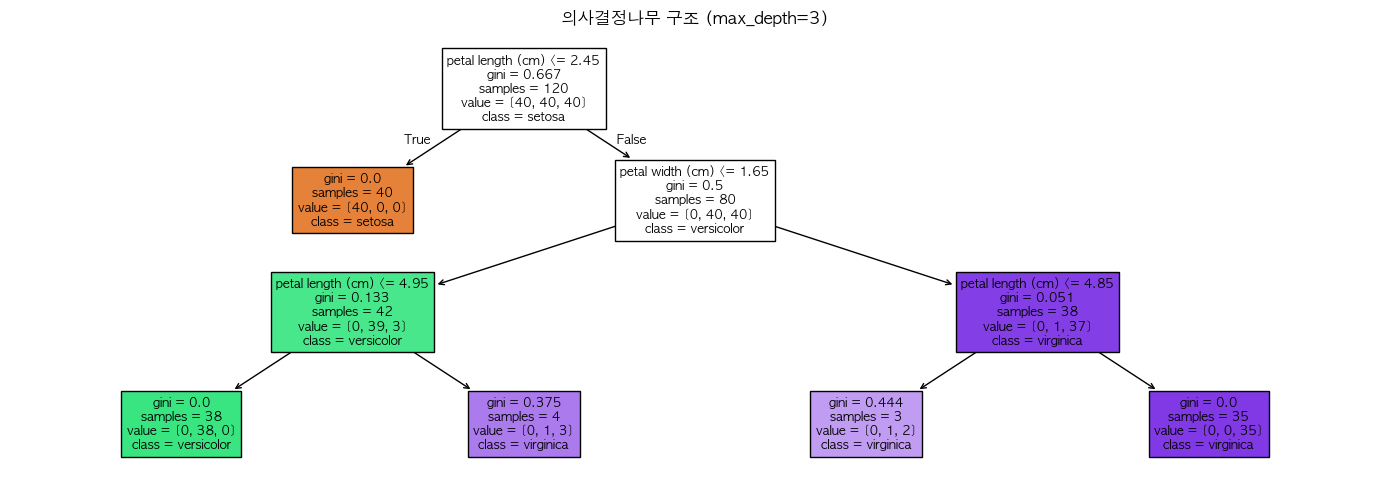

In [8]:
# sklearn.tree에서 의사결정나무 모델과 시각화 함수를 가져옴
# DecisionTreeClassifier : 분류용 의사결정나무
# plot_tree              : 트리 구조를 그림으로 표현
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ============================================================
# 의사결정나무 실습 (iris 3분류)
# ============================================================

# 학습/테스트 데이터 분할 (Cell 6의 X, y 재사용)
# stratify=y : 클래스(0,1,2) 비율을 유지하며 분할 → 불균형 방지
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 모델 생성 ──────────────────────────────────────────────
# max_depth=3   : 나무 깊이 최대 3단계 제한 → 과적합 방지
#                 None이면 완전히 자라서 Train 100% 도달 (과적합)
# random_state  : 재현성 보장 (같은 값 = 항상 같은 결과)
dt = DecisionTreeClassifier(max_depth=3, random_state=42)

# ── 모델 학습 ──────────────────────────────────────────────
# fit(X_train, y_train) : 데이터를 보고 분기 조건을 학습
dt.fit(X_tr, y_tr)

# ── 예측 ───────────────────────────────────────────────────
# predict() : 각 샘플의 클래스(0, 1, 2)를 예측해 배열로 반환
y_pred_dt = dt.predict(X_te)

# ── 성능 출력 ──────────────────────────────────────────────
# Train > Test 이면 과적합, 비슷하면 일반화 잘 된 것
print(f"Train Accuracy: {accuracy_score(y_tr, dt.predict(X_tr)):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_te, y_pred_dt):.4f}")

# ── 트리 구조 시각화 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))   # 가로 14, 세로 5인 그래프 공간 생성

# plot_tree() 매개변수 설명:
#   dt               : 학습된 DecisionTreeClassifier 객체
#   feature_names    : 각 분기에서 사용한 변수 이름 표시
#   class_names      : 잎 노드(최종 예측)에 클래스 이름 표시
#   filled=True      : 각 노드를 클래스별 색으로 채움 (다수 클래스 = 짙은 색)
#   fontsize=9       : 노드 안 글자 크기 (작을수록 전체가 잘 보임)
#   ax=ax            : 그릴 axes 객체 지정
plot_tree(dt, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True, fontsize=9, ax=ax)

ax.set_title('의사결정나무 구조 (max_depth=3)')   # 그래프 제목 설정
plt.tight_layout()   # 요소 간격 자동 조정
plt.show()           # 화면에 출력

## 2. 앙상블 (Ensemble) — 보팅 / 배깅 / 부스팅 / 스태킹

### 직관적 비유
> **전문가 여러 명에게 묻고 합치기** — 한 명보다 여러 명의 의견이 더 정확하다

---

### ① 보팅 (Voting)
> 서로 **다른 종류**의 모델을 여러 개 학습시켜 **다수결(Hard)** 또는 **확률 평균(Soft)** 으로 최종 예측

```
[로지스틱회귀] → 생존
[결정나무]    → 사망      →  다수결 → 생존 (2:1)
[KNN]        → 생존
```

| 방식 | 설명 |
|---|---|
| **Hard Voting** | 각 모델의 예측 클래스로 다수결 |
| **Soft Voting** | 각 모델의 확률을 평균내어 가장 높은 클래스 선택 (더 정확) |

---

### ② 배깅 (Bagging)
> **같은 모델**을 여러 개 만들되, 각자 **다른 샘플(복원추출)** 로 학습 → 병렬 처리

```
원본 데이터 → 샘플1 → 트리1 ↘
           → 샘플2 → 트리2 →  다수결 → 최종 예측
           → 샘플3 → 트리3 ↗
```
- 대표 모델: **RandomForest**
- 특징: 빠름(병렬), 과적합에 강함

---

### ③ 부스팅 (Boosting)
> 이전 모델이 **틀린 샘플**에 가중치를 높여 다음 모델이 집중 학습 → 순차 처리

```
트리1 학습 → 오답 확인 → 오답에 가중치↑ → 트리2 학습 → ... → 합산
```
- 대표 모델: **GradientBoosting, XGBoost, LightGBM**
- 특징: 성능 높음, 느림(순차), 과적합 주의

---

### ④ 스태킹 (Stacking)
> 여러 모델의 **예측값을 새로운 입력**으로 사용해 메타 모델이 최종 판단

```
[로지스틱회귀] → 예측값 ↘
[결정나무]    → 예측값 →  메타모델(로지스틱) → 최종 예측
[랜덤포레스트] → 예측값 ↗
```
- 가장 복잡하고 구현 어려움
- 성능은 가장 높을 수 있으나 과적합 위험 있음

---

### 네 가지 비교 요약

| | 보팅 | 배깅 | 부스팅 | 스태킹 |
|---|---|---|---|---|
| 모델 종류 | 다른 모델 | 같은 모델 | 같은 모델 | 다른 모델 |
| 학습 방식 | 병렬 | 병렬 | **순차** | 2단계 |
| 대표 알고리즘 | VotingClassifier | RandomForest | GBM, **XGBoost** | StackingClassifier |
| 속도 | 빠름 | 빠름 | 느림 | 가장 느림 |
| 과적합 | 보통 | 강함 | 주의 필요 | 주의 필요 |

### 📝 시험 출제 포인트
- **RandomForest** = 배깅 + 랜덤 피처 선택
- **GradientBoosting / XGBoost** = 부스팅 (오류 보완하며 순차 학습)
- **Soft Voting** > Hard Voting (확률 평균이 더 정확)
- 모든 앙상블 트리 모델은 `feature_importances_` 제공

In [ ]:
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression as LR
from sklearn.neighbors import KNeighborsClassifier

# XGBoost: pip install xgboost 필요 (설치 안 됐으면 GBM으로 대체)
try:
    from xgboost import XGBClassifier
    USE_XGB = True
    print("✅ XGBoost 사용 가능")
except ImportError:
    USE_XGB = False
    print("⚠️ xgboost 미설치 → GradientBoosting으로 대체 (pip install xgboost)")

# ============================================================
# 공통으로 사용할 개별 모델 객체 정의
# ============================================================
dt_m  = DecisionTreeClassifier(max_depth=3, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
lr_m  = LR(random_state=42, max_iter=200)
knn_m = KNeighborsClassifier(n_neighbors=5)

# XGBoost 모델 (설치된 경우에만 생성)
# 주요 매개변수:
#   n_estimators  : 부스팅 라운드(트리) 수
#   max_depth     : 개별 트리 깊이 (기본 6, 클수록 복잡)
#   learning_rate : 각 트리의 기여도 축소 (작을수록 보수적, 기본 0.3)
#   subsample     : 각 트리 학습에 사용할 샘플 비율 (과적합 방지)
if USE_XGB:
    xgb_clf = XGBClassifier(n_estimators=100, max_depth=4,
                            learning_rate=0.1, subsample=0.8,
                            random_state=42, eval_metric='logloss',
                            verbosity=0)

# ============================================================
# ① 보팅 (Voting) — XGBoost 포함 가능
# ============================================================
# voting='soft': 각 모델의 확률을 평균 → 더 정확 (권장)
# XGBoost도 predict_proba()를 지원하므로 soft voting에 사용 가능
if USE_XGB:
    voting_clf = VotingClassifier(
        estimators=[
            ('lr',  lr_m),    # 로지스틱 회귀
            ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),  # 배깅
            ('xgb', XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                                  random_state=42, eval_metric='logloss', verbosity=0)),  # 부스팅
        ],
        voting='soft'
    )
else:
    voting_clf = VotingClassifier(
        estimators=[
            ('lr',  lr_m),
            ('dt',  DecisionTreeClassifier(max_depth=3, random_state=42)),
            ('knn', knn_m),
        ],
        voting='soft'
    )

# ============================================================
# ④ 스태킹 (Stacking) — XGBoost를 베이스 또는 메타 모델로 사용 가능
# ============================================================
# estimators : 1단계 베이스 모델 (예측값 생성)
# final_estimator : 2단계 메타 모델 (베이스 예측값을 입력으로 최종 판단)
# cv=5        : 교차검증으로 베이스 모델 예측 생성 (데이터 누수 방지)
if USE_XGB:
    stacking_clf = StackingClassifier(
        estimators=[
            ('dt',  DecisionTreeClassifier(max_depth=3, random_state=42)),  # 베이스 1
            ('rf',  RandomForestClassifier(n_estimators=50, random_state=42)),  # 베이스 2
            ('xgb', XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.1,
                                  random_state=42, eval_metric='logloss', verbosity=0)),  # 베이스 3
        ],
        final_estimator=LR(random_state=42),  # 메타 모델: 로지스틱 회귀
        cv=5
    )
else:
    stacking_clf = StackingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(max_depth=3, random_state=42)),
            ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
        ],
        final_estimator=LR(random_state=42),
        cv=5
    )

# ============================================================
# 전체 모델 성능 비교
# ============================================================
models = {
    '① Voting (Soft)'  : voting_clf,
    '② Bagging (RF)'   : rf_clf,
    '③ Boosting (GBM)' : gb_clf,
    '④ Stacking'       : stacking_clf,
}
if USE_XGB:
    models['③ Boosting (XGB)'] = XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        random_state=42, eval_metric='logloss', verbosity=0
    )

print(f"\n{'모델':25s} | {'Train':>8} | {'Test':>8}")
print("-" * 48)
for name, m in models.items():
    m.fit(X_tr, y_tr)
    tr_acc = accuracy_score(y_tr, m.predict(X_tr))
    te_acc = accuracy_score(y_te, m.predict(X_te))
    print(f"{name:25s} | {tr_acc:>8.4f} | {te_acc:>8.4f}")

In [ ]:
# ============================================================
# 변수 중요도(Feature Importance) 비교 시각화
# ============================================================
# feature_importances_ : 트리 기반 모델이 제공하는 속성
#   → 각 변수가 예측에 기여한 비율 (0~1 사이, 합계=1)
#   → 값이 클수록 예측에 중요한 변수

# 앞 셀의 models 딕셔너리 키가 변경되었으므로 직접 모델 변수 사용
# rf_clf : 앞 셀에서 학습된 RandomForest 모델
# gb_clf : 앞 셀에서 학습된 GradientBoosting 모델
rf_model = rf_clf
gb_model = gb_clf

# ── 나란히 2개 그래프 배치 ──────────────────────────────────
# plt.subplots(1, 2) : 1행 2열 → 좌우에 그래프 2개
# figsize=(12, 4)    : 전체 가로 12인치, 세로 4인치
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── 각 모델의 중요도 막대그래프 그리기 ────────────────────
for ax, m, name in zip(axes, [rf_model, gb_model], ['Random Forest', 'Gradient Boosting']):
    # pd.Series로 변환 : feature_importances_ 배열 + 변수 이름 인덱스
    # .sort_values()   : 기본값 ascending=True → 작은 값이 위로 (barh에서 큰 게 위에 보임)
    imp = pd.Series(m.feature_importances_, index=iris.feature_names).sort_values()

    # ax.barh() : 수평 막대그래프
    #   imp.index  : Y축 레이블 (변수 이름)
    #   imp.values : 막대 길이 (중요도 수치)
    #   color      : 막대 색상 ('steelblue' = 강청색)
    ax.barh(imp.index, imp.values, color='steelblue')

    ax.set_title(f'{name}\n변수 중요도')   # 모델명 두 줄로 제목 표시
    ax.set_xlabel('Importance')            # X축 레이블

plt.tight_layout()   # 두 그래프 간격 자동 조정
plt.show()
print("→ 중요도가 높은 변수 = 예측에 더 큰 영향")
print("→ RF와 GB 결과가 비슷하면 해당 변수가 실제로 중요한 것")

---
## ✏️ AICE 실전 문제 풀기

> **타이타닉 데이터로 생존 여부 예측**  
> 아래 빈칸을 채워 전체 모델링 파이프라인을 완성하세요.

### 문제 조건
- 데이터: `pandas/data/titanic_train.csv`
- 목표: `survived` (0=사망, 1=생존) 예측
- 전처리: 결측치 처리, 원핫인코딩
- 모델: RandomForestClassifier
- 평가: Accuracy, Classification Report 출력

### 📝 풀이 순서
1. 데이터 로드 및 결측치 확인
2. 결측치 처리 (age→중앙값, embark_town→최빈값)
3. 원핫인코딩 (sex, embark_town)
4. X, y 분리 → train_test_split
5. 모델 학습 및 예측
6. 성능 평가

In [ ]:
# ===== ✏️ 문제: 아래 ___를 채워 완성하세요 =====
# (타이타닉 데이터로 랜덤포레스트 생존 예측 전체 파이프라인)

# 1. 데이터 로드
df = pd.read_csv(r'pandas/data/titanic_train.csv')

# 2. 결측치 처리
df['age'] = df['age'].fillna(___)                 # age: 중앙값으로 채우기
df['embark_town'] = df['embark_town'].fillna(___) # embark_town: 최빈값으로 채우기

# 3. 원핫인코딩
# columns=___ : 범주형 변수 이름 리스트 입력
# drop_first=True : 첫 번째 더미 변수 제거 (다중공선성 방지)
df = pd.get_dummies(df, columns=___, drop_first=True, dtype='i1')

# 4. X(입력), y(정답) 분리 및 데이터 분할
X = df.drop(columns=[___])   # survived 컬럼 제외한 나머지가 입력 변수
y = df[___]                   # survived 컬럼이 예측 대상(정답)

# test_size=___ : 테스트 비율 (일반적으로 0.2 = 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=___, random_state=42)

# 5. 모델 생성 및 학습
# n_estimators=___ : 트리 개수 (보통 100)
rf = RandomForestClassifier(n_estimators=___, random_state=42)
rf.___(X_train, y_train)       # fit() : 학습 메서드

# 6. 예측
y_pred = rf.___(X_test)        # predict() : 클래스 예측 메서드

# 7. 평가
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['사망(0)', '생존(1)']))

TypeError: Input must be a list-like for parameter `columns`

### 💡 정답 확인 (풀어본 후 열어보세요)

In [ ]:
# ===== ✅ 정답 코드 (풀어본 후 확인하세요) =====

# 1. 데이터 로드
df = pd.read_csv(r'pandas/data/titanic_train.csv')

# 2. 결측치 처리
# df['age'].median()    : age 컬럼의 중앙값 계산 (이상치 영향 적음)
# df['embark_town'].mode()[0] : 최빈값 반환 → [0]으로 첫 번째 값만 추출
df['age'] = df['age'].fillna(df['age'].median())
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# 3. 원핫인코딩
# columns=['sex','embark_town'] : 범주형 변수만 인코딩
# drop_first=True : 첫 더미 제거 (sex→male열만, embark_town→Southampton 제외 2개)
# dtype='i1'      : 0/1을 int8(1바이트)로 저장 → 메모리 절약
df = pd.get_dummies(df, columns=['sex', 'embark_town'], drop_first=True, dtype='i1')

# 4. X, y 분리 및 데이터 분할
# drop(columns=['survived']) : survived를 제외한 모든 컬럼 = 입력 변수
X = df.drop(columns=['survived'])
y = df['survived']   # 예측 대상: 0(사망), 1(생존)

# test_size=0.2 : 전체 891명 중 20%(약 178명)를 테스트용으로
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 모델 학습
# RandomForest는 스케일링(StandardScaler) 불필요 — 트리는 값의 크기가 아닌 분기 순서만 사용
# n_estimators=100 : 트리 100개 → 100명 전문가의 다수결
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)   # fit() : 모델 학습

# 6. 예측
# predict() : 각 승객에 대해 0(사망) 또는 1(생존) 예측
y_pred = rf.predict(X_test)

# 7. 평가
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# classification_report() : 정밀도, 재현율, F1 등을 한번에 출력
# target_names : 0→'사망(0)', 1→'생존(1)'로 표시
print(classification_report(y_test, y_pred, target_names=['사망(0)', '생존(1)']))

# 8. 변수 중요도 확인 (보너스)
# feature_importances_ : 각 변수의 기여도 (합계=1.0)
# sort_values(ascending=False) : 내림차순 → 중요한 변수가 위에
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("=== 변수 중요도 상위 5개 ===")
print(imp.head())   # .head() : 상위 5개만 출력 (기본값 n=5)